<a href="https://colab.research.google.com/github/sonia-rafique/Internship-DataScience-Tasks./blob/main/Task-02/Credit_Risk_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipykernel_8353/865484215.py:24: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)
/tmp/ipykernel_8353/865484215.py:27: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try u

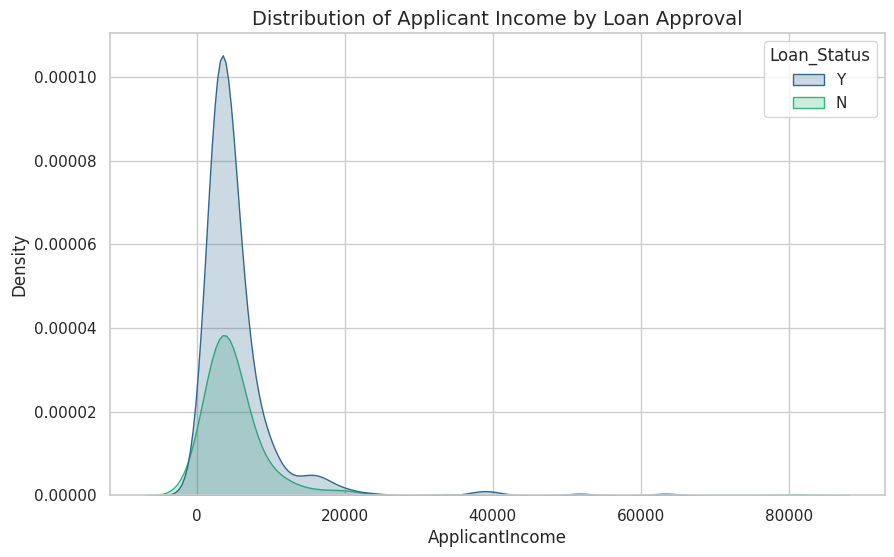

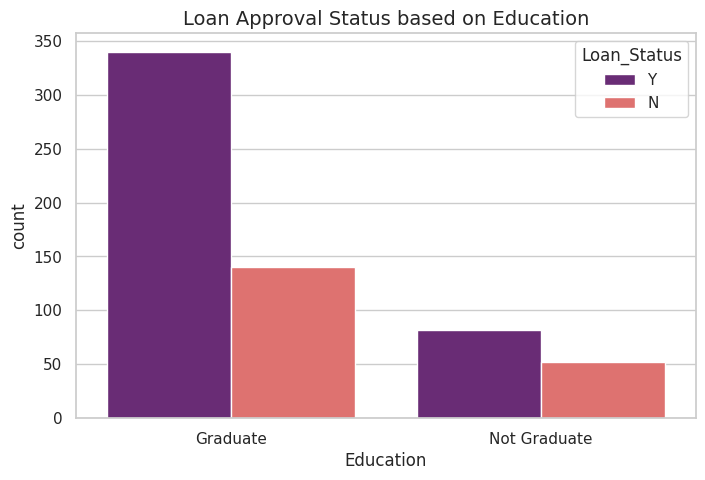

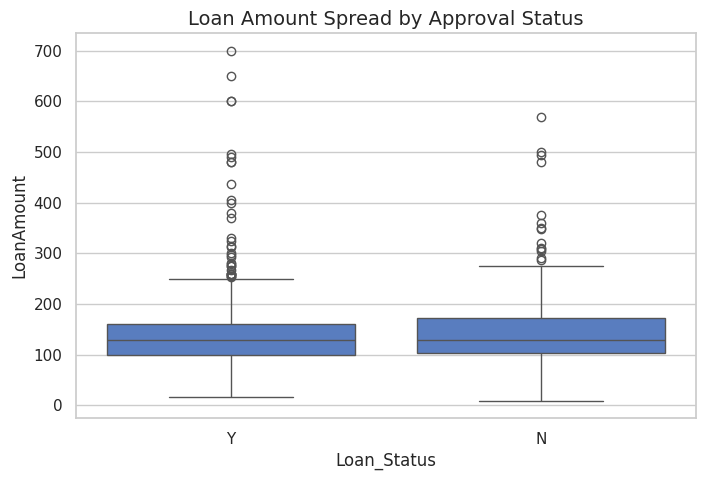


--- Model Performance ---
Overall Accuracy: 78.86%


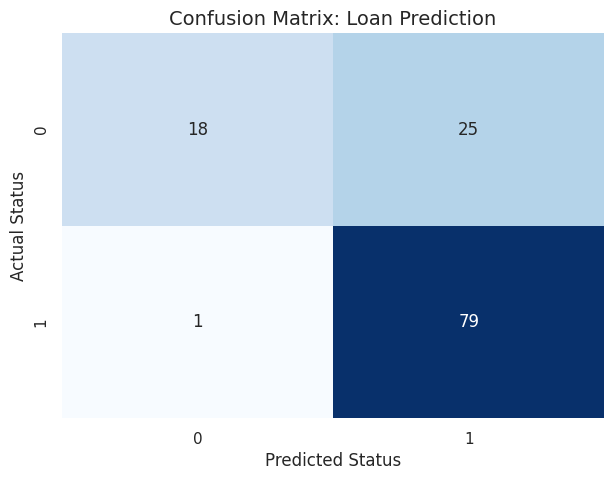


Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.42      0.58        43
           1       0.76      0.99      0.86        80

    accuracy                           0.79       123
   macro avg       0.85      0.70      0.72       123
weighted avg       0.83      0.79      0.76       123



In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)

# Load the dataset
df = pd.read_csv('LoanPrediction.csv')

# --- 1. PREPROCESSING & DATA CLEANING ---

df['Dependents'] = df['Dependents'].replace('3+', 3)
df['Dependents'] = pd.to_numeric(df['Dependents'], errors='coerce')

# Fill categorical missing values with the 'Mode'
cat_cols = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Credit_History', 'Loan_Amount_Term']
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

# Fill numerical missing values (LoanAmount) with 'Median' to handle outliers
df['LoanAmount'].fillna(df['LoanAmount'].median(), inplace=True)

# --- 2. EXPLORATORY DATA ANALYSIS (EDA) ---

# A. Visualizing Income Distribution by Loan Status
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='ApplicantIncome', hue='Loan_Status', fill=True, palette='viridis')
plt.title('Distribution of Applicant Income by Loan Approval', fontsize=14)
plt.show()

# B. Visualizing Education vs Loan Status
plt.figure(figsize=(8, 5))
sns.countplot(x='Education', hue='Loan_Status', data=df, palette='magma')
plt.title('Loan Approval Status based on Education', fontsize=14)
plt.show()

# C. Boxplot for Loan Amount
plt.figure(figsize=(8, 5))
sns.boxplot(x='Loan_Status', y='LoanAmount', data=df)
plt.title('Loan Amount Spread by Approval Status', fontsize=14)
plt.show()

# --- 3. FEATURE ENGINEERING & ENCODING ---

# Create 'Total_Income' feature for better predictive power
df['Total_Income'] = df['ApplicantIncome'] + df['CoapplicantIncome']

# Apply Log Transformation to normalize skewed data
df['Total_Income_Log'] = np.log(df['Total_Income'] + 1)
df['LoanAmount_Log'] = np.log(df['LoanAmount'] + 1)

# Encode categorical variables into numeric values
le = LabelEncoder()
encode_cols = ['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status']
for col in encode_cols:
    df[col] = le.fit_transform(df[col].astype(str))

# Final Feature Selection: Drop non-predictive or redundant raw columns
X = df.drop(columns=['Loan_ID', 'Loan_Status', 'ApplicantIncome', 'CoapplicantIncome', 'Total_Income', 'LoanAmount'])
y = df['Loan_Status']

# Split data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- 4. MODEL TRAINING ---

# Initialize and train Logistic Regression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Generate predictions
y_pred = model.predict(X_test)

# --- 5. EVALUATION ---

# Accuracy Score
accuracy = accuracy_score(y_test, y_pred)
print(f"\n--- Model Performance ---")
print(f"Overall Accuracy: {accuracy * 100:.2f}%")

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix: Loan Prediction', fontsize=14)
plt.xlabel('Predicted Status')
plt.ylabel('Actual Status')
plt.show()

#  Detailed Classification Report
print("\nClassification Report:\n", classification_report(y_test, y_pred))